In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import random
import plotly.express as px
import plotly.io as pio

import matplotlib.pyplot as plt
from ml_world_cup_predictor.config import DATA_DIRECTORY
from ml_world_cup_predictor.data_transformation import transform_match_data
from ml_world_cup_predictor.feature_engineering import generate_match_features
from ml_world_cup_predictor.plot_theme import apply_theme

pio.renderers.default = 'browser'
apply_theme()

def load_data(data_directory: Path) -> dict[str,pd.DataFrame]:
    frames = {file_path.stem : pd.read_csv(file_path) for file_path in sorted(data_directory.glob('*csv'))}

    for frame in frames.values():
        if 'date' in frame.columns:
            frame['date'] = pd.to_datetime(frame['date'],errors = 'coerce')
    
    return frames



played,not_played = transform_match_data(DATA_DIRECTORY)
df = generate_match_features(played)


Using cached dataset at: C:\Users\eoinm\Documents\ml_world_cup_predictor\data\international-football-results


In [8]:
df.tail(20)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,shootout_id,shootout_winner,year,result,goal_diff,home_elo,away_elo,home_form,away_form
48832,2026-06-30,Ivory Coast,Norway,1.0,2.0,FIFA World Cup,Arlington,United States,True,2026-06-30_Ivory Coast_Norway,NaN,2026,L,1.0,2055.555098,2213.047645,0.755556,0.733333
48833,2026-06-30,France,Sweden,3.0,0.0,FIFA World Cup,East Rutherford,United States,True,2026-06-30_France_Sweden,NaN,2026,W,3.0,2484.799269,1953.838005,0.822222,0.422222
48834,2026-06-30,Mexico,Ecuador,2.0,0.0,FIFA World Cup,Mexico City,Mexico,False,2026-06-30_Mexico_Ecuador,NaN,2026,W,2.0,2203.785312,2189.708752,0.688889,0.533333
48835,2026-07-01,England,DR Congo,2.0,1.0,FIFA World Cup,Atlanta,United States,True,2026-07-01_England_DR Congo,NaN,2026,W,1.0,2379.370293,1967.316824,0.777778,0.666667
48836,2026-07-01,Belgium,Senegal,3.0,2.0,FIFA World Cup,Seattle,United States,True,2026-07-01_Belgium_Senegal,NaN,2026,W,1.0,2143.343722,2076.204423,0.733333,0.644444
48837,2026-07-01,United States,Bosnia and Herzegovina,2.0,0.0,FIFA World Cup,Santa Clara,United States,False,2026-07-01_United States_Bosnia and Herzegovina,NaN,2026,W,2.0,2070.264668,1821.395714,0.555556,0.577778
48838,2026-07-02,Spain,Austria,3.0,0.0,FIFA World Cup,Inglewood,United States,True,2026-07-02_Spain_Austria,NaN,2026,W,3.0,2517.054951,2068.544328,0.755556,0.711111
48839,2026-07-02,Portugal,Croatia,2.0,1.0,FIFA World Cup,Toronto,Canada,True,2026-07-02_Portugal_Croatia,NaN,2026,W,1.0,2291.720804,2146.996770,0.755556,0.755556
48840,2026-07-02,Switzerland,Algeria,2.0,0.0,FIFA World Cup,Vancouver,Canada,True,2026-07-02_Switzerland_Algeria,NaN,2026,W,2.0,2216.061277,2041.401869,0.711111,0.711111
48841,2026-07-03,Australia,Egypt,1.0,1.0,FIFA World Cup,Arlington,United States,True,2026-07-03_Australia_Egypt,Egypt,2026,L,0.0,2076.091530,1993.092451,0.577778,0.555556


I want to get see the trend over time across the below areas:
- Total Goals in a game
- Total Home Goals & Total Away Goals
- Goal Difference Per Game

In [9]:
# Getting Running Sum of Totals Goals First
df['match_goals'] = df['home_score']+df['away_score']

#Grouping by Year to see change Year on Year
df_goals = df.groupby(df.date.dt.year).agg(
    total_goal_py = ('match_goals','sum'),
    total_games_py = ('date','count'),
    total_goal_diff = ('goal_diff','sum'),
    gpg = ('match_goals','mean'),
    gdpg = ('goal_diff','mean')
)

df_goals.tail()


,total_goal_py,total_games_py,total_goal_diff,gpg,gdpg
date,,,,,
2022,2413.0,959,1429.0,2.516163,1.490094
2023,2903.0,1030,1765.0,2.818447,1.713592
2024,3243.0,1230,1897.0,2.636585,1.542276
2025,2786.0,986,1710.0,2.825558,1.734280
2026,1146.0,407,652.0,2.815725,1.601966


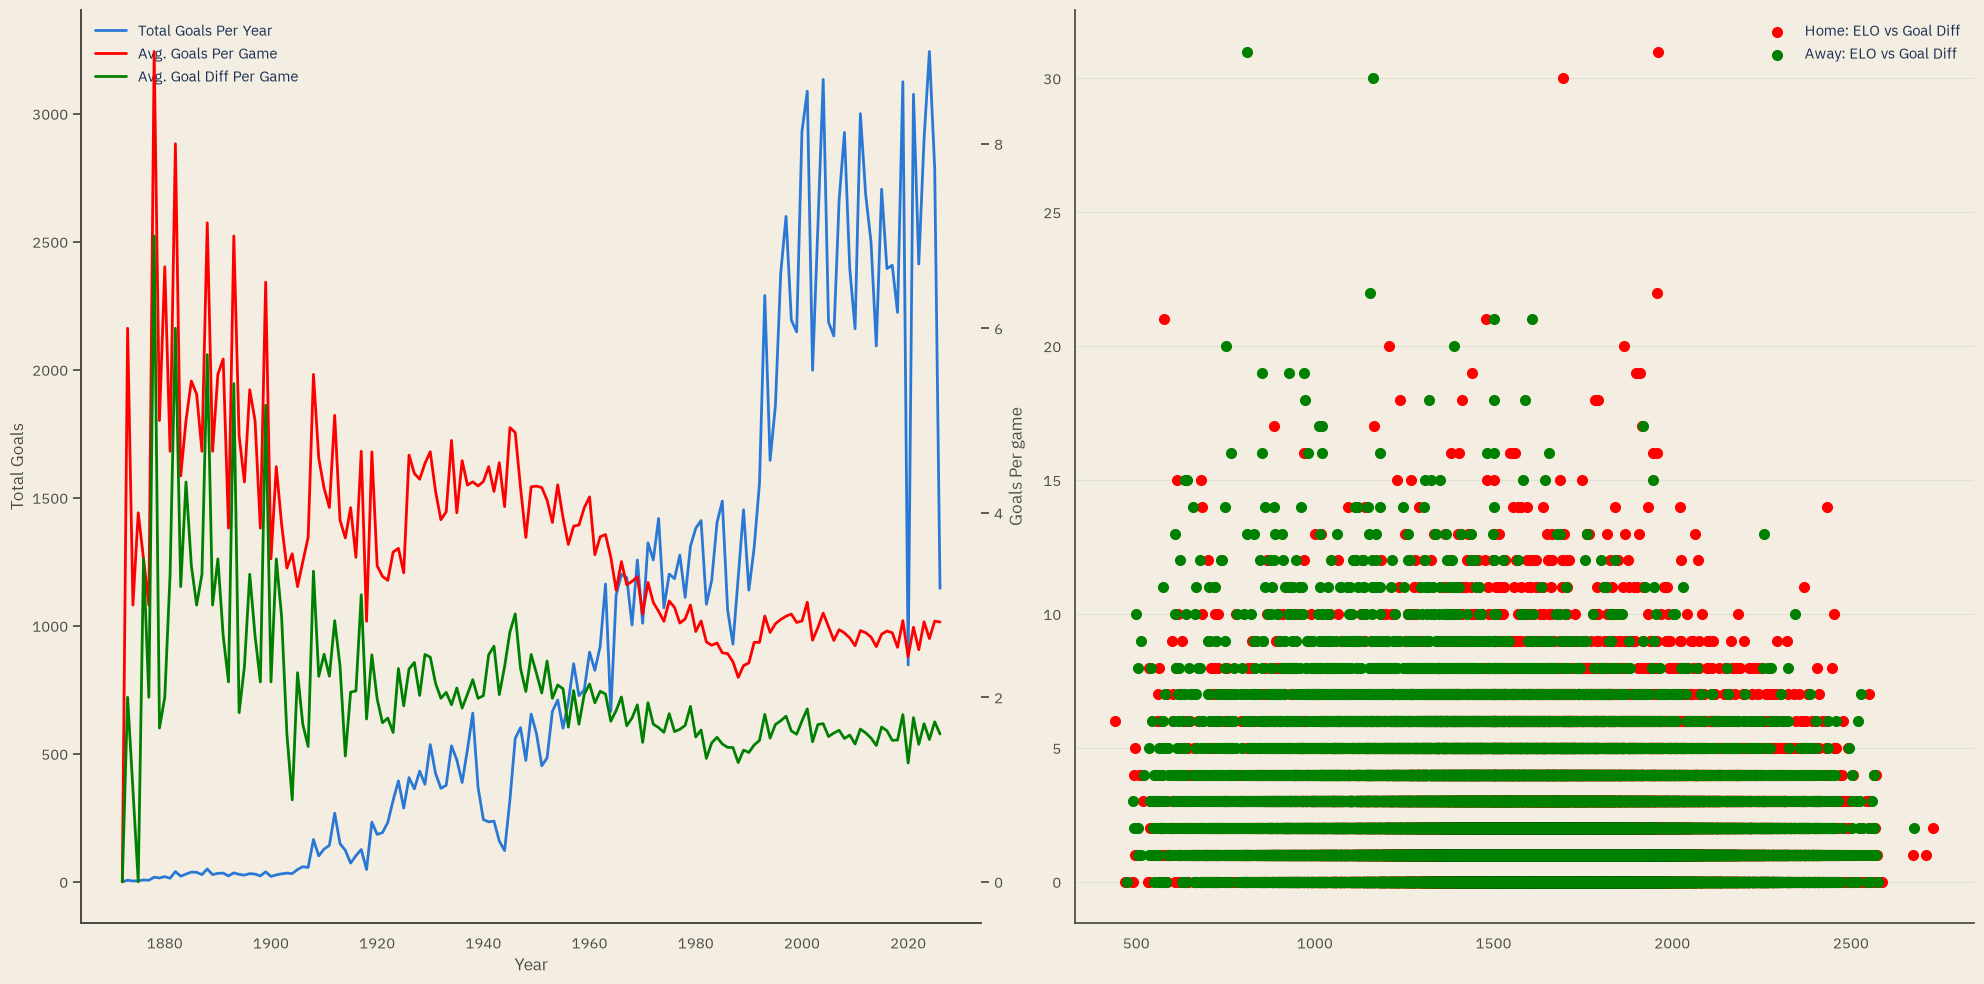

In [11]:
fig, axes = plt.subplots(nrows= 1, ncols=2,figsize = (20,10))

ax1, ax3 = axes.flatten()

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Goals')
lines1 = ax1.plot(df_goals.index,df_goals['total_goal_py'],label = 'Total Goals Per Year')

ax2 = ax1.twinx()
ax2.set_ylabel('Goals Per game')
lines2 = ax2.plot(df_goals.index,df_goals['gpg'],color= 'red',label = 'Avg. Goals Per Game')
lines3 = ax2.plot(df_goals.index,df_goals['gdpg'],color = 'green',label = 'Avg. Goal Diff Per Game')

ax1.grid(False)
ax2.grid(False)

lines = lines1 + lines2 + lines3
labs = [line.get_label() for line in lines]
ax1.legend(lines, labs, loc=2)

# Try to see if there is any relationship between ELO and Goal Differences
ax3.scatter(df['home_elo'],df['goal_diff'],color='red', label = 'Home: ELO vs Goal Diff')
ax3.scatter(df['away_elo'],df['goal_diff'],color='green',label = 'Away: ELO vs Goal Diff')

ax3.legend()

fig.tight_layout()
